In [3]:
import numpy as np

np.random.seed(42)

def relu(z):
    return np.maximum(0,z)

def relu_derivative(z):
    return (z>0).astype(float)                # return 1 if z>0

def softmax(z):
    exp_z = np.exp(z - z.max(axis=1, keepdims= True))
    return exp_z / exp_z.sum(axis=1, keepdims=True)

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

In [4]:
# MNIST: 784 inputs → 128 hidden → 64 hidden → 10 outputs

class NeuralNetwork:

    def __init__(self, layer_sizes):
        """
        layer_sizes: e.g. [784, 128, 64, 10]
        """
        self.layers = layer_sizes
        self.weights = []
        self.biases  = []


        for i in range(len(layer_sizes) - 1):
            n_in  = layer_sizes[i]
            n_out = layer_sizes[i + 1]
            W = np.random.randn(n_in, n_out) * np.sqrt(2 / n_in)
            b = np.zeros((1, n_out))
            self.weights.append(W)
            self.biases.append(b)

        print(f"Network: {' → '.join(str(s) for s in layer_sizes)}")
        total_params = sum(W.size + b.size
                          for W, b in zip(self.weights, self.biases))
        print(f"Total parameters: {total_params:,}")
        
            
    def forward(self, X):
        """
        X shape: (batch_size, 784)
        Returns: output probabilities, shape (batch_size, 10)
        """
        self.activations = [X]   # store for backprop later
        self.z_values    = []

        current = X

        # Hidden layers — ReLU activation
        for i in range(len(self.weights) - 1):
            z = current @ self.weights[i] + self.biases[i]
            a = relu(z)
            self.z_values.append(z)
            self.activations.append(a)
            current = a
        
        z_out = current @ self.weights[-1] + self.biases[-1]
        a_out = softmax(z_out)
        self.z_values.append(z_out)
        self.activations.append(a_out)

        return a_out

    def loss(self, y_pred, y_true):
        """
        Cross-entropy loss for multi-class classification
        y_true: one-hot encoded, shape (batch_size, 10)
        y_pred: softmax output, shape (batch_size, 10)
        """
        n = y_true.shape[0]
        return -np.sum(y_true * np.log(y_pred + 1e-8)) / n        

In [5]:
#  Testing the Forward Pass

#  Creating a Network
nn = NeuralNetwork([784,128,64,10])

X_fake = np.random.randn(5,784)

output = nn.forward(X_fake)

print(f"\nInput shape:  {X_fake.shape}")
print(f"Output shape: {output.shape}")
print(f"\nPrediction probabilities for image 0:")
for digit, prob in enumerate(output[0]):
    bar = '█' * int(prob * 50)
    print(f"  Digit {digit}: {prob:.4f}  {bar}")

print(f"\nPredicted digit: {output[0].argmax()}")
print(f"Sum of probs:    {output[0].sum():.6f}")

Network: 784 → 128 → 64 → 10
Total parameters: 109,386

Input shape:  (5, 784)
Output shape: (5, 10)

Prediction probabilities for image 0:
  Digit 0: 0.0341  █
  Digit 1: 0.0912  ████
  Digit 2: 0.0028  
  Digit 3: 0.1504  ███████
  Digit 4: 0.0659  ███
  Digit 5: 0.1974  █████████
  Digit 6: 0.0522  ██
  Digit 7: 0.2473  ████████████
  Digit 8: 0.1454  ███████
  Digit 9: 0.0133  

Predicted digit: 7
Sum of probs:    1.000000


In [6]:
#  Some Exercises related to this model

# Question 1: how many parameters does a deeper network have?
nn_deep = NeuralNetwork([784, 256, 128, 64, 10])

# Question 2: what happens to output shape with different batch sizes?
X_batch_32 = np.random.rand(32, 784)
out = nn_deep.forward(X_batch_32)
print(out.shape)

# Question 3: what does relu do to negative values?
test = np.array([-3, -1, 0, 1, 3])
print(relu(test))   # predict before running

# Question 4: verify softmax sums to 1 for every sample in batch
print(out.sum(axis=1))

Network: 784 → 256 → 128 → 64 → 10
Total parameters: 242,762
(32, 10)
[0 0 0 1 3]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1.]


In [7]:
#  DAY 2  LOSS FUNCTION

def one_hot(y, num_classes=10):
    """
    Convert class labels to one-hot encoding
    y = [3, 7, 1] → [[0,0,0,1,0,0,0,0,0,0],
                      [0,0,0,0,0,0,0,1,0,0],
                      [0,1,0,0,0,0,0,0,0,0]]
    """
    n = len(y)
    one_hot_matrix = np.zeros((n, num_classes))
    one_hot_matrix[np.arange(n), y] = 1
    return one_hot_matrix


labels = np.array([3, 7, 1])
print(one_hot(labels))


#  BACKPROPAGATION

def backward(self, y_true_onehot, learning_rate=0.01):
    """
    Compute gradients and update all weights and biases
    using chain rule backwards through the network
    """
    n = y_true_onehot.shape[0]   # batch size
    n_layers = len(self.weights)

    # Storage for gradients
    dW = [None] * n_layers
    db = [None] * n_layers

    #  Step 1: Output layer gradient 
    # For softmax + cross-entropy combined, gradient simplifies to:
    # dL/dZ_out = ŷ - y
    delta = self.activations[-1] - y_true_onehot  # (batch, 10)

    #  Step 2: Walk backwards through layer
    for i in range(n_layers - 1, -1, -1):
        # Gradient of weights = previous activation.T @ delta
        dW[i] = self.activations[i].T @ delta / n
        db[i] = delta.mean(axis=0, keepdims=True)

        if i > 0:
            # Propagate delta to previous layer
            # delta flows back through weights and ReLU
            delta = (delta @ self.weights[i].T) * relu_derivative(
                        self.z_values[i-1])

    #  Step 3: Update weights
    for i in range(n_layers):
        self.weights[i] -= learning_rate * dW[i]
        self.biases[i]  -= learning_rate * db[i]

# Attach backward to the class
NeuralNetwork.backward = backward


#  TRAINING LOOP

def train(self, X, y, epochs=100, lr=0.01, batch_size=64):
    losses = []
    n = len(X)
    n_classes = self.layers[-1]

    for epoch in range(epochs):
        idx             = np.random.permutation(n)
        X_shuf, y_shuf = X[idx], y[idx]

        epoch_loss = 0
        n_batches  = 0

        for start in range(0, n, batch_size):
            end     = start + batch_size
            X_batch = X_shuf[start:end]
            y_batch = y_shuf[start:end]

            # Forward
            y_pred = self.forward(X_batch)

            # Loss — pass correct num_classes
            y_oh       = one_hot(y_batch, n_classes)   # ← fixed
            loss       = self.loss(y_pred, y_oh)
            epoch_loss += loss
            n_batches  += 1

            # Backward + update
            self.backward(y_oh, learning_rate=lr)

        avg_loss = epoch_loss / n_batches
        losses.append(avg_loss)

        if epoch % 10 == 0:
            preds    = self.forward(X).argmax(axis=1)
            accuracy = (preds == y).mean()
            print(f"Epoch {epoch:3d} | Loss: {avg_loss:.4f} "
                  f"| Accuracy: {accuracy:.3f}")

    return losses

NeuralNetwork.train = train

[[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]]


Network: 20 → 64 → 32 → 3
Total parameters: 3,523
Epoch   0 | Loss: 1.2923 | Accuracy: 0.405
Epoch  10 | Loss: 0.8217 | Accuracy: 0.646
Epoch  20 | Loss: 0.7166 | Accuracy: 0.696
Epoch  30 | Loss: 0.6436 | Accuracy: 0.725
Epoch  40 | Loss: 0.5883 | Accuracy: 0.757
Epoch  50 | Loss: 0.5465 | Accuracy: 0.782
Epoch  60 | Loss: 0.5112 | Accuracy: 0.804
Epoch  70 | Loss: 0.4742 | Accuracy: 0.819
Epoch  80 | Loss: 0.4479 | Accuracy: 0.831
Epoch  90 | Loss: 0.4182 | Accuracy: 0.843

Test accuracy: 0.780


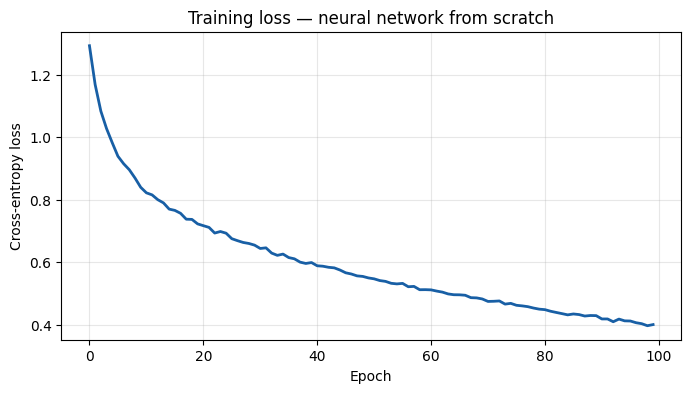

In [8]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_toy, y_toy = make_classification(
    n_samples=1000,
    n_features=20,
    n_classes=3,
    n_informative=10,
    random_state=42
)

scaler = StandardScaler()
X_toy  = scaler.fit_transform(X_toy)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_toy, y_toy, test_size=0.2, random_state=42
)

#  Building and Training
nn_toy = NeuralNetwork([20, 64, 32, 3])
losses = nn_toy.train(X_tr, y_tr, epochs=100, lr=0.01)

preds    = nn_toy.forward(X_te).argmax(axis=1)
accuracy = (preds == y_te).mean()
print(f"\nTest accuracy: {accuracy:.3f}")

# Ploting loss curve
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(losses, color='#185FA5', linewidth=2)
plt.title('Training loss — neural network from scratch')
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy loss')
plt.grid(alpha=0.3)
plt.show()

In [9]:
# Deeper network
nn_deep = NeuralNetwork([20, 128, 64, 32, 3])
losses = nn_deep.train(X_tr, y_tr, epochs=100, lr=0.01)
preds  = nn_deep.forward(X_te).argmax(axis=1)
print(f"Deeper network: {(preds == y_te).mean():.3f}")

# More epochs
nn_long = NeuralNetwork([20, 64, 32, 3])
losses = nn_long.train(X_tr, y_tr, epochs=300, lr=0.01)
preds  = nn_long.forward(X_te).argmax(axis=1)
print(f"More epochs: {(preds == y_te).mean():.3f}")

Network: 20 → 128 → 64 → 32 → 3
Total parameters: 13,123
Epoch   0 | Loss: 1.2920 | Accuracy: 0.414
Epoch  10 | Loss: 0.7259 | Accuracy: 0.686
Epoch  20 | Loss: 0.5800 | Accuracy: 0.770
Epoch  30 | Loss: 0.4868 | Accuracy: 0.806
Epoch  40 | Loss: 0.4233 | Accuracy: 0.845
Epoch  50 | Loss: 0.3619 | Accuracy: 0.874
Epoch  60 | Loss: 0.3120 | Accuracy: 0.902
Epoch  70 | Loss: 0.2712 | Accuracy: 0.919
Epoch  80 | Loss: 0.2310 | Accuracy: 0.938
Epoch  90 | Loss: 0.2006 | Accuracy: 0.951
Deeper network: 0.825
Network: 20 → 64 → 32 → 3
Total parameters: 3,523
Epoch   0 | Loss: 1.6227 | Accuracy: 0.284
Epoch  10 | Loss: 0.9047 | Accuracy: 0.583
Epoch  20 | Loss: 0.7746 | Accuracy: 0.661
Epoch  30 | Loss: 0.6822 | Accuracy: 0.703
Epoch  40 | Loss: 0.6308 | Accuracy: 0.736
Epoch  50 | Loss: 0.5827 | Accuracy: 0.762
Epoch  60 | Loss: 0.5493 | Accuracy: 0.776
Epoch  70 | Loss: 0.5212 | Accuracy: 0.789
Epoch  80 | Loss: 0.4952 | Accuracy: 0.804
Epoch  90 | Loss: 0.4650 | Accuracy: 0.818
Epoch 100 |

Loading MNIST...
Dataset shape: (70000, 784)
Labels: [0 1 2 3 4 5 6 7 8 9]


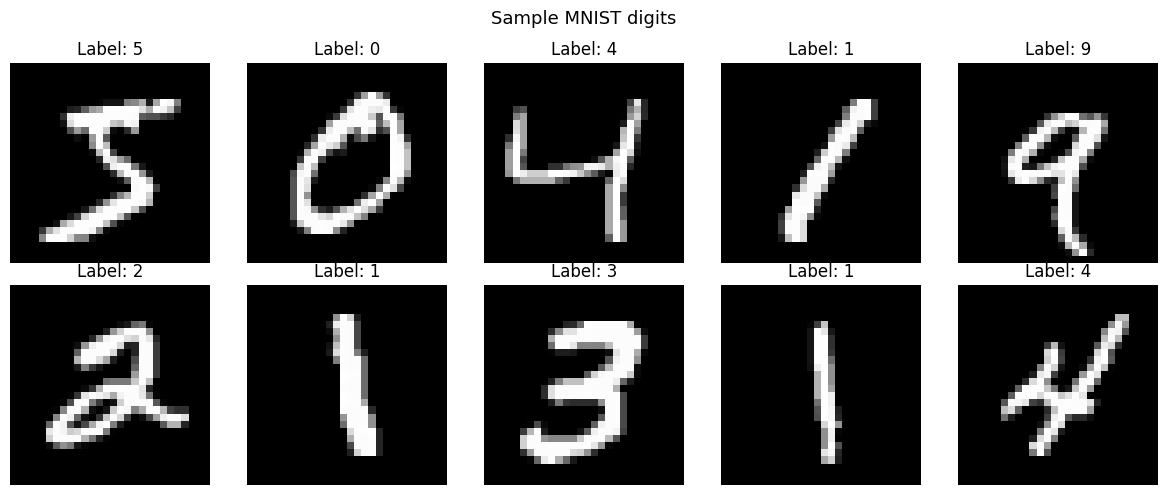


Train: (60000, 784), Test: (10000, 784)
Network: 784 → 128 → 64 → 10
Total parameters: 109,386

Training...
Epoch   0 | Loss: 0.3204 | Accuracy: 0.941
Epoch  10 | Loss: 0.0221 | Accuracy: 0.996
Epoch  20 | Loss: 0.0034 | Accuracy: 0.999

Final test accuracy: 0.9784


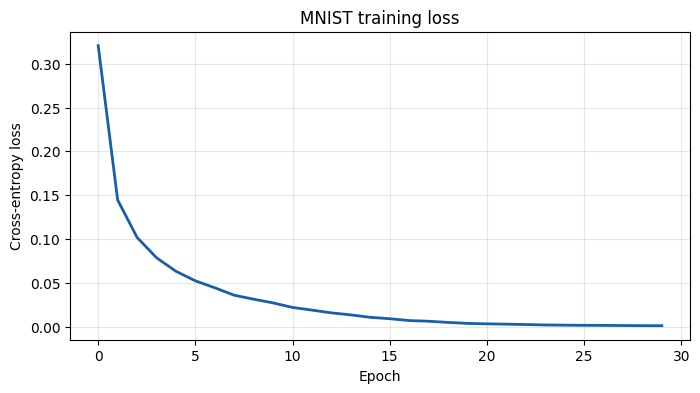

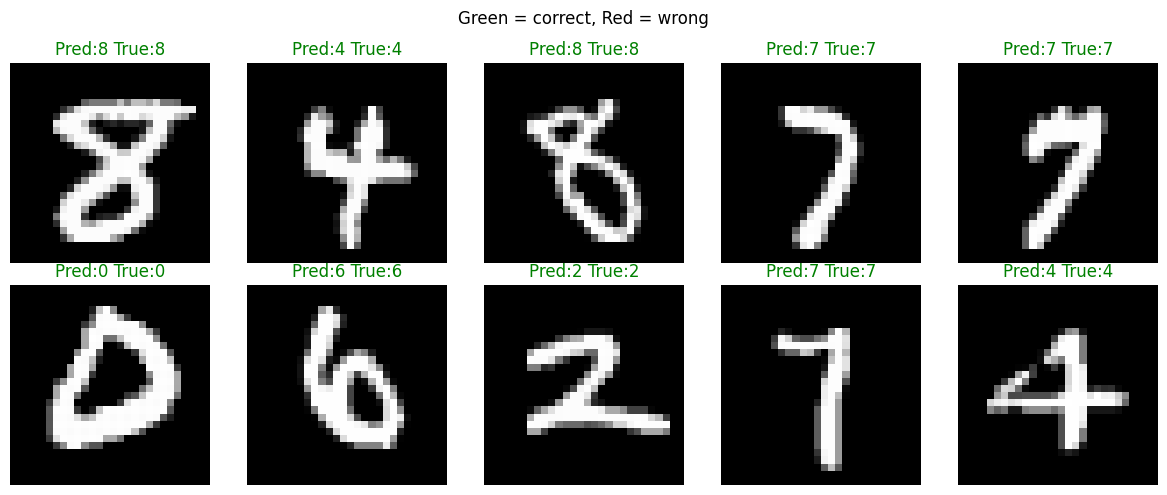

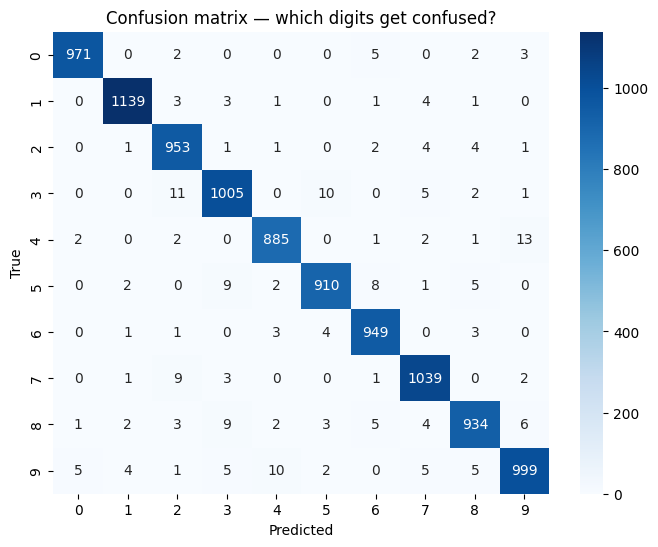


Most confused pair: 4 mistaken for 9
Count: 13


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#  Loading MNIST 
print("Loading MNIST...")
mnist   = fetch_openml('mnist_784', version=1, as_frame=False)
X_mnist = mnist.data.astype(float)  
y_mnist = mnist.target.astype(int)     

print(f"Dataset shape: {X_mnist.shape}")
print(f"Labels: {np.unique(y_mnist)}")  # 0-9

# ── Visualise some digits ─────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_mnist[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Label: {y_mnist[i]}")
    ax.axis('off')
plt.suptitle('Sample MNIST digits', fontsize=13)
plt.tight_layout()
plt.show()

# ── Preprocess ────────────────────────────────────────────
X_mnist = X_mnist / 255.0

X_tr, X_te, y_tr, y_te = train_test_split(
    X_mnist, y_mnist,
    test_size=10000,
    random_state=42
)

print(f"\nTrain: {X_tr.shape}, Test: {X_te.shape}")

# ── Build network ─────────────────────────────────────────
nn_mnist = NeuralNetwork([784, 128, 64, 10])

# ── Train ─────────────────────────────────────────────────
print("\nTraining...")
losses = nn_mnist.train(
    X_tr, y_tr,
    epochs=30,
    lr=0.1,
    batch_size=64
)

# ── Evaluate ──────────────────────────────────────────────
preds    = nn_mnist.forward(X_te).argmax(axis=1)
accuracy = (preds == y_te).mean()
print(f"\nFinal test accuracy: {accuracy:.4f}")

# ── Plotting loss curve ───────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(losses, color='#185FA5', linewidth=2)
plt.title('MNIST training loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy loss')
plt.grid(alpha=0.3)
plt.show()

# ── Visualise predictions ─────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_te[i].reshape(28, 28), cmap='gray')
    pred  = preds[i]
    truth = y_te[i]
    color = 'green' if pred == truth else 'red'
    ax.set_title(f"Pred:{pred} True:{truth}", color=color)
    ax.axis('off')
plt.suptitle('Green = correct, Red = wrong', fontsize=12)
plt.tight_layout()
plt.show()

# ── Confusion matrix ──────────────────────────────────────
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_te, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10),
            yticklabels=range(10))
plt.title('Confusion matrix — which digits get confused?')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# ── Most confused pairs ───────────────────────────────────
np.fill_diagonal(cm, 0)   # remove correct predictions
confused = np.unravel_index(cm.argmax(), cm.shape)
print(f"\nMost confused pair: {confused[0]} mistaken for {confused[1]}")
print(f"Count: {cm[confused]}")

Total mistakes: 216 / 10000


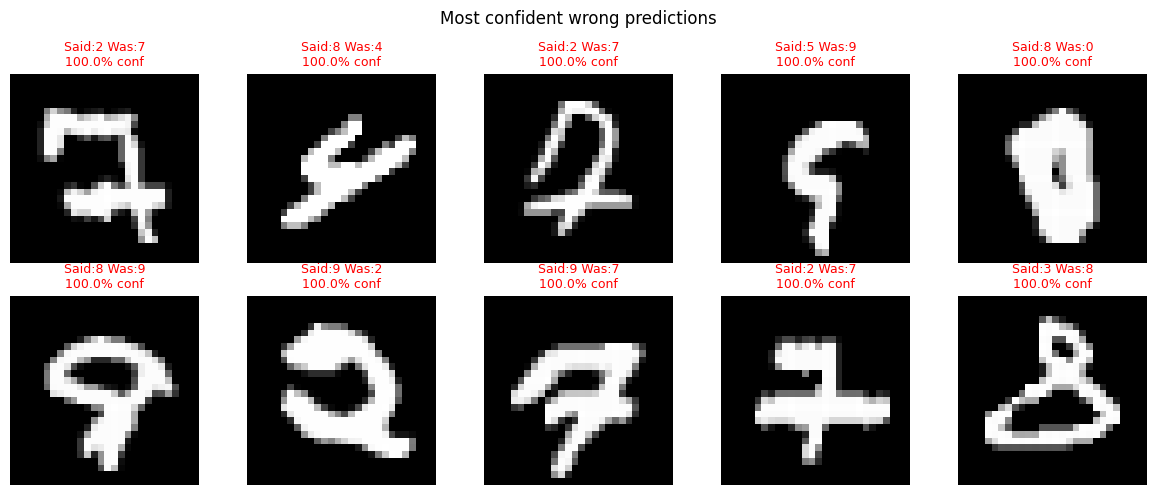

In [11]:
# Find the actual wrong predictions and show them
wrong_idx = np.where(preds != y_te)[0]
print(f"Total mistakes: {len(wrong_idx)} / {len(y_te)}")

# Show the hardest mistakes — ones your model was MOST confident about
wrong_probs = nn_mnist.forward(X_te[wrong_idx])
confidence  = wrong_probs.max(axis=1)   # how confident was it?
most_confident_wrong = wrong_idx[confidence.argsort()[-10:]]

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    idx  = most_confident_wrong[i]
    pred = preds[idx]
    true = y_te[idx]
    conf = confidence[confidence.argsort()[-10:]][i]
    ax.imshow(X_te[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f"Said:{pred} Was:{true}\n{conf:.1%} conf", 
                 color='red', fontsize=9)
    ax.axis('off')

plt.suptitle('Most confident wrong predictions', fontsize=12)
plt.tight_layout()
plt.show()